# 27 模型可解释性完整演示

本教程基于 `examples/hscredit_yyp.xlsx` 的真实放款样本，演示 HSCredit 中模型解释相关的主要方法：

1. 使用 SHAP 解释全局特征重要性与单样本贡献；
2. 生成不利原因码、代表样本、相关性、聚类、交互效应与稳定性报告；
3. 绘制中文模型解释图；
4. 在业务约束下生成反事实候选方案；
5. 将模型解释结果写入 `ModelReport` Excel 报告。

> SHAP 是 HSCredit 的基础依赖，无需安装额外的 `explain` extra。本教程不使用 LIME。

## Goal

完成本教程后，你可以区分并使用三类解释结果：

- **SHAP 贡献**：说明模型为什么产生当前输出；
- **不利原因码**：只保留风险方向一致的不利贡献，便于业务沟通；
- **反事实候选方案**：在给定模型和约束下搜索可行变化，不代表真实因果效果。

## Setup

### 1. 定位仓库和验证数据

Notebook 同时兼容从仓库根目录和 `examples` 目录启动。首次使用请先执行 `pip install -e .`。

In [1]:
from pathlib import Path
import sys

current_dir = Path.cwd().resolve()
repository_candidates = [current_dir, current_dir.parent]
repository_root = next(
    (path for path in repository_candidates if (path / "hscredit").is_dir() and (path / "examples").is_dir()),
    None,
)
if repository_root is None:
    raise FileNotFoundError("未找到 hscredit 仓库根目录，请从仓库根目录或 examples 目录启动 Notebook")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

examples_dir = repository_root / "examples"
data_path = examples_dir / "hscredit_yyp.xlsx"
output_path = examples_dir / "model_interpretability_report.xlsx"
if not data_path.exists():
    raise FileNotFoundError(f"验证数据不存在: {data_path}")

print(f"仓库目录: {repository_root}")
print(f"验证数据: {data_path}")

仓库目录: E:\workspace\hscredit
验证数据: E:\workspace\hscredit\examples\hscredit_yyp.xlsx


### 2. 导入依赖并设置可复现参数

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from IPython.display import display
from openpyxl import load_workbook
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from hscredit.core.models import CounterfactualExplainer, ExplanationResult, ModelExplainer
from hscredit.report import ModelReport

RANDOM_STATE = 42
MAX_EXPLAIN_SAMPLES = 80
N_BOOTSTRAP = 20
FEATURES = ["衡枢鉴真分老客版", "近六个月非银多头机构数", "青云24"]
TARGET = "FPD"

print(f"SHAP 版本: {shap.__version__}")

SHAP 版本: 0.49.1


### Key Assumptions

- `FPD=1` 代表需要解释的风险类别，模型输出越高表示风险越高；
- 缺失特征使用训练前总体中位数填补，仅用于演示，不替代生产特征处理流程；
- 为控制运行时间，只解释最多 80 个测试样本，稳定性分析执行 20 次样本 Bootstrap；
- SHAP、原因码和反事实均解释模型行为，不证明变量与违约之间存在因果关系。

## Steps

### 3. 加载并准备真实数据

In [3]:
raw_data = pd.read_excel(data_path)
missing_columns = [column for column in FEATURES + [TARGET] if column not in raw_data.columns]
if missing_columns:
    raise ValueError(f"输入文件缺少必要字段: {missing_columns}")

model_data = raw_data[FEATURES + [TARGET]].copy()
for column in FEATURES + [TARGET]:
    model_data[column] = pd.to_numeric(model_data[column], errors="coerce")
model_data = model_data.dropna(subset=[TARGET])
model_data[FEATURES] = model_data[FEATURES].replace([np.inf, -np.inf], np.nan)
model_data[FEATURES] = model_data[FEATURES].fillna(model_data[FEATURES].median(numeric_only=True)).fillna(0)
model_data[TARGET] = model_data[TARGET].astype(int)

data_summary = pd.DataFrame(
    {
        "指标": ["样本数", "特征数", "坏样本数", "坏样本率"],
        "结果": [
            len(model_data),
            len(FEATURES),
            int(model_data[TARGET].sum()),
            float(model_data[TARGET].mean()),
        ],
    }
)
display(data_summary)
display(model_data.head())

,指标,结果
0,样本数,970.0000
1,特征数,3.0000
2,坏样本数,136.0000
3,坏样本率,0.1402


,衡枢鉴真分老客版,近六个月非银多头机构数,青云24,FPD
0,0.0242,51,656,0
1,0.0492,56,565,0
2,0.0546,68,708,0
3,0.0899,45,555,0
4,0.0678,67,581,0


### 4. 切分数据并训练演示模型

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    model_data[FEATURES],
    model_data[TARGET],
    test_size=0.30,
    stratify=model_data[TARGET],
    random_state=RANDOM_STATE,
)

model = RandomForestClassifier(
    n_estimators=40,
    max_depth=5,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)
test_probability = model.predict_proba(X_test)[:, 1]
model_summary = pd.DataFrame(
    {
        "指标": ["训练样本数", "测试样本数", "测试集AUC"],
        "结果": [len(X_train), len(X_test), roc_auc_score(y_test, test_probability)],
    }
)
display(model_summary)

,指标,结果
0,训练样本数,679.0000
1,测试样本数,291.0000
2,测试集AUC,0.5662


### 5. 计算结构化 SHAP 解释

`model_output="probability"` 表示 SHAP 基准值和贡献可以加总回目标类别 `1` 的预测概率。返回的 `ExplanationResult` 固定保存样本索引、特征顺序、输出尺度、背景数据摘要和数据指纹。

In [5]:
explainer = ModelExplainer(
    model,
    background_data=X_train,
    model_output="probability",
    target_class=1,
    max_background=100,
    random_state=RANDOM_STATE,
)
explanation = explainer.explain(X_test, max_samples=MAX_EXPLAIN_SAMPLES)

explanation_summary = pd.DataFrame(
    {
        "项目": ["结果类型", "解释算法", "输出尺度", "目标类别", "解释样本数", "特征数", "数据指纹"],
        "结果": [
            type(explanation).__name__,
            explanation.explainer_type,
            explanation.model_output,
            explanation.target_class,
            len(explanation.data),
            len(explanation.feature_names),
            explanation.dataset_fingerprint,
        ],
    }
)
display(explanation_summary)

,项目,结果
0,结果类型,ExplanationResult
1,解释算法,tree
2,输出尺度,probability
3,目标类别,1
4,解释样本数,80
5,特征数,3
6,数据指纹,86590b801fba662abf2be8996368f9d50403625e0b61983e54b8fd86bc6beb55


### 6. 查看全局特征重要性

In [6]:
global_report = explainer.get_global_report(explanation)
display(global_report.round(6))

# 兼容旧调用方式：直接返回按平均绝对 SHAP 值排序的 Series。
shap_importance = explainer.get_shap_importance()
display(shap_importance.to_frame())

,特征,平均绝对SHAP值,SHAP重要性占比,平均SHAP值,正向影响占比,负向影响占比,影响标准差,P25,P50,P75,原生特征重要性,Pearson相关系数,Spearman相关系数,SHAP排名,原生排名,排名差
0,衡枢鉴真分老客版,0.0238,0.4108,-0.0021,0.2125,0.7875,0.0413,-0.0188,-0.0141,-0.0065,0.3962,0.7148,0.3255,1,1.0000,0.0000
1,青云24,0.0192,0.3319,0.0034,0.4875,0.5125,0.0250,-0.0139,-0.0007,0.0177,0.3340,-0.5809,-0.6341,2,2.0000,0.0000
2,近六个月非银多头机构数,0.0149,0.2573,-0.0001,0.2500,0.7500,0.0235,-0.0124,-0.0066,-0.0001,0.2698,0.4107,0.1509,3,3.0000,0.0000


,SHAP重要性
衡枢鉴真分老客版,0.0238
青云24,0.0192
近六个月非银多头机构数,0.0149


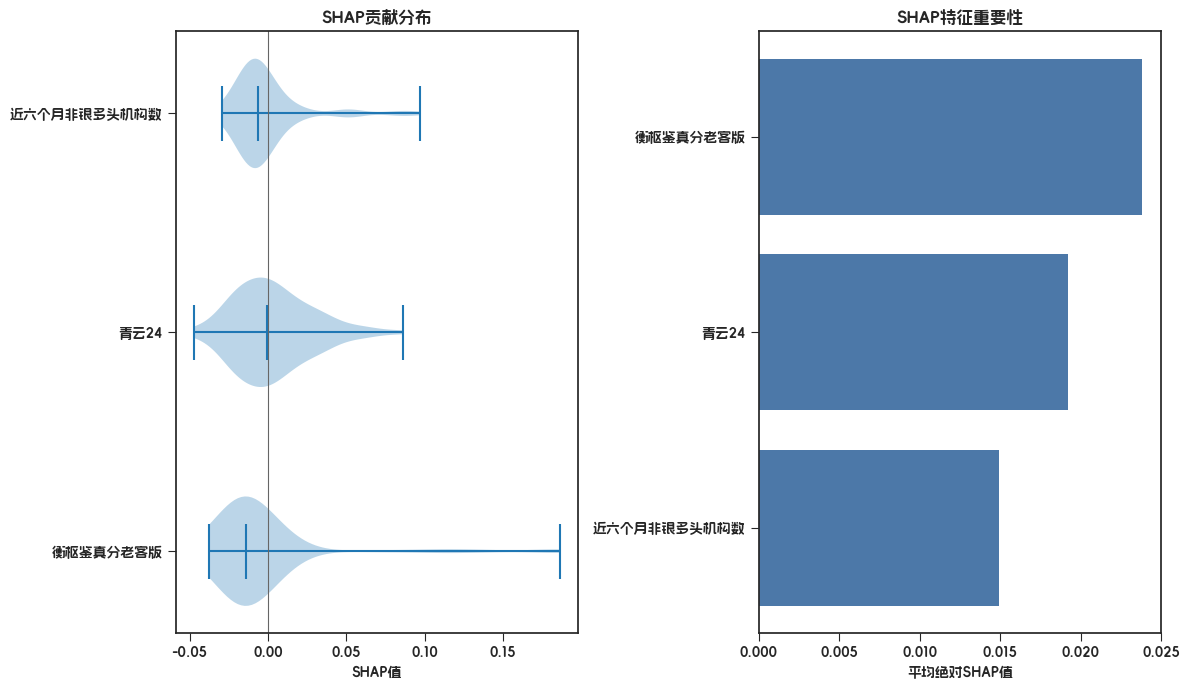

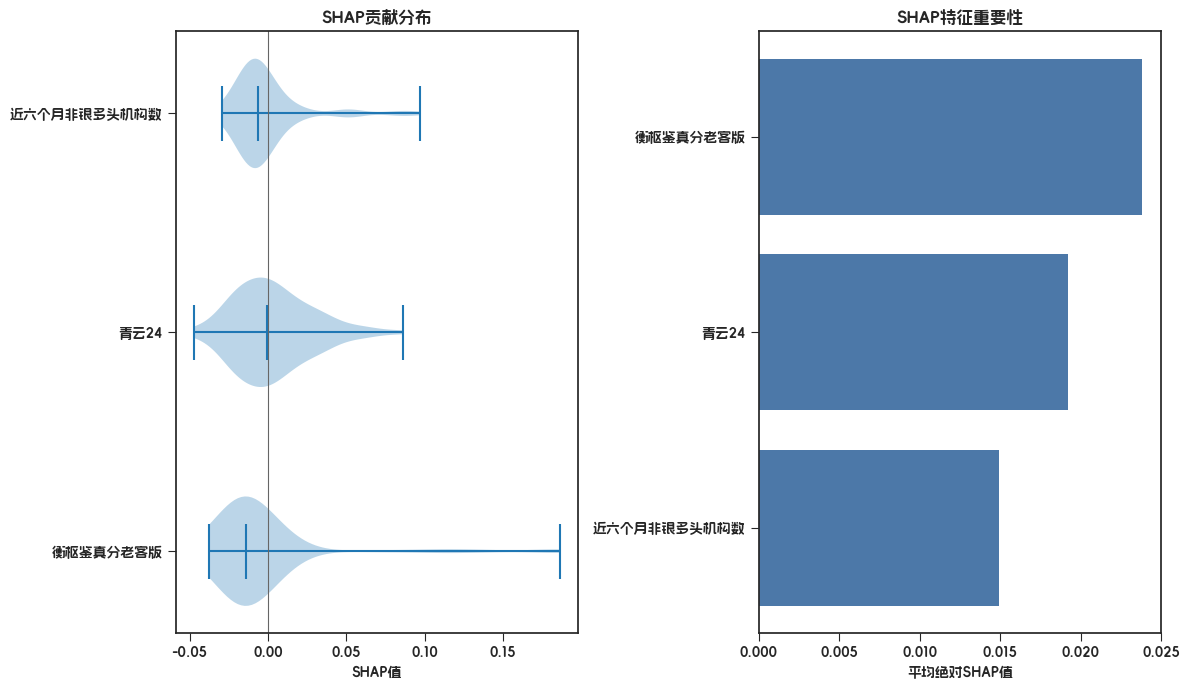

In [7]:
explainer.plot_importance_overview(explanation, max_display=len(FEATURES))

### 7. 分析单个样本与不利原因码

In [8]:
representative_samples = explainer.select_representative_samples(explanation, threshold=0.5)
display(representative_samples)

highest_risk_sample_id = representative_samples.iloc[0]["样本索引"]
sample_report = explainer.get_sample_report(
    explanation,
    sample_id=highest_risk_sample_id,
    top_n=len(FEATURES),
)
display(sample_report.round(6))

,样本索引,选择理由,模型输出,风险排名,阈值距离
0,491,最高风险、最接近决策阈值、最不确定样本、总绝对贡献最大,0.3271,1,0.1729
1,536,最低风险,0.0564,80,0.4436
2,213,最接近总体中位输出,0.0984,40,0.4016


,样本索引,目标类别,模型输出,基准值,特征,特征值,SHAP值,绝对贡献,贡献方向,累计贡献,贡献排名
0,491,1,0.3271,0.1187,衡枢鉴真分老客版,0.2067,0.1171,0.1171,提高输出,0.1171,1
1,491,1,0.3271,0.1187,近六个月非银多头机构数,77.0000,0.0817,0.0817,提高输出,0.1988,2
2,491,1,0.3271,0.1187,青云24,463.0000,0.0096,0.0096,提高输出,0.2084,3


In [9]:
reason_codes = explainer.get_reason_codes(
    explanation,
    keep=3,
    risk_direction="higher_output_higher_risk",
    feature_map={
        "衡枢鉴真分老客版": "衡枢鉴真分（老客版）",
        "近六个月非银多头机构数": "近六个月非银多头机构数",
        "青云24": "青云24指标",
    },
    reason_map={
        "衡枢鉴真分老客版": {"code": "MODEL_001", "description": "鉴真分表现对风险输出产生不利影响"},
        "近六个月非银多头机构数": {"code": "MODEL_002", "description": "近期非银多头表现对风险输出产生不利影响"},
        "青云24": {"code": "MODEL_003", "description": "青云24指标表现对风险输出产生不利影响"},
    },
)
display(reason_codes[reason_codes["样本索引"] == highest_risk_sample_id])

,样本索引,原因排名,特征,业务特征名,特征值,SHAP值,风险贡献,原因码,原因描述,原因状态,目标类别,输出尺度,风险方向
63,491,1.0000,衡枢鉴真分老客版,衡枢鉴真分（老客版）,0.2067,0.1171,0.1171,MODEL_001,鉴真分表现对风险输出产生不利影响,存在不利贡献,1,probability,higher_output_higher_risk
64,491,2.0000,近六个月非银多头机构数,近六个月非银多头机构数,77.0000,0.0817,0.0817,MODEL_002,近期非银多头表现对风险输出产生不利影响,存在不利贡献,1,probability,higher_output_higher_risk
65,491,3.0000,青云24,青云24指标,463.0000,0.0096,0.0096,MODEL_003,青云24指标表现对风险输出产生不利影响,存在不利贡献,1,probability,higher_output_higher_risk


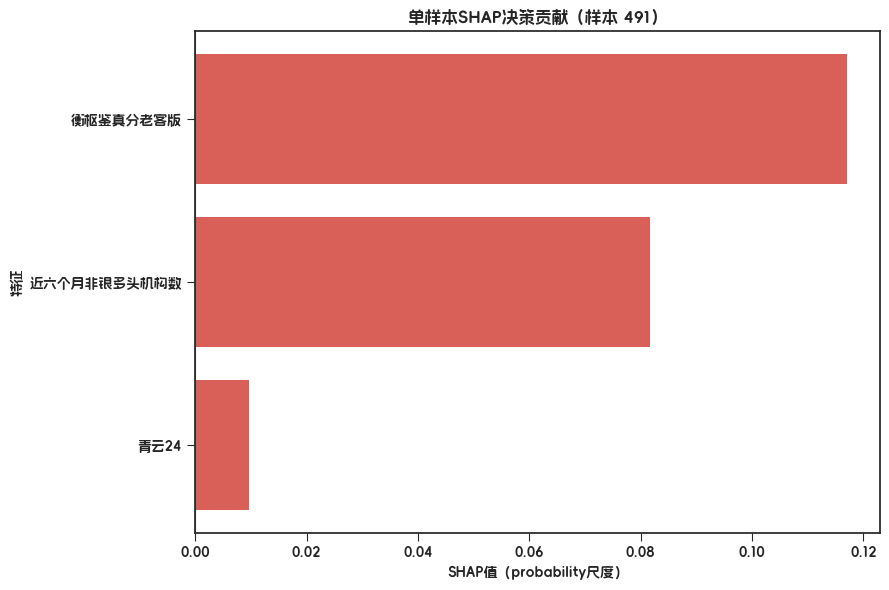

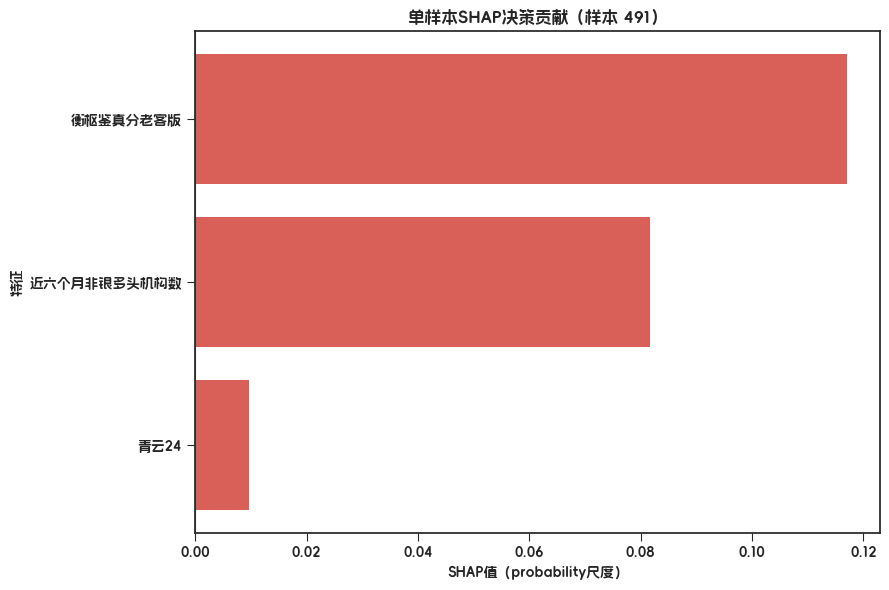

In [10]:
explainer.plot_decision(explanation, sample_id=highest_risk_sample_id, max_display=len(FEATURES))

### 8. 查看贡献分布和多样本热力图

当前最重要特征: 衡枢鉴真分老客版


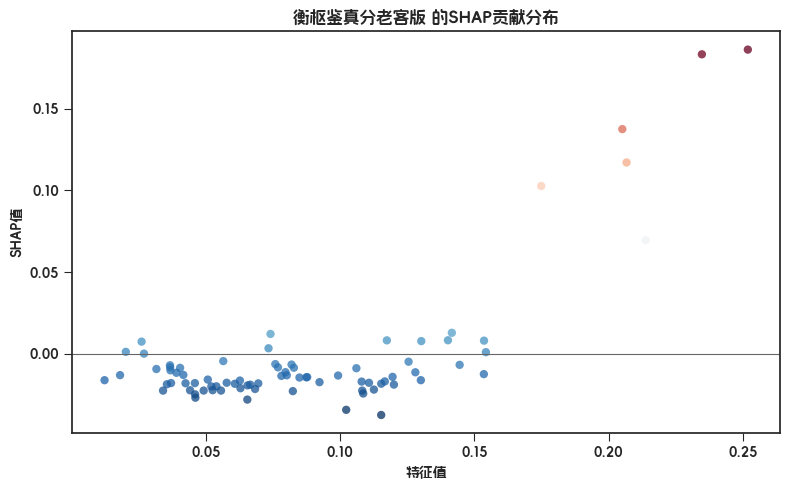

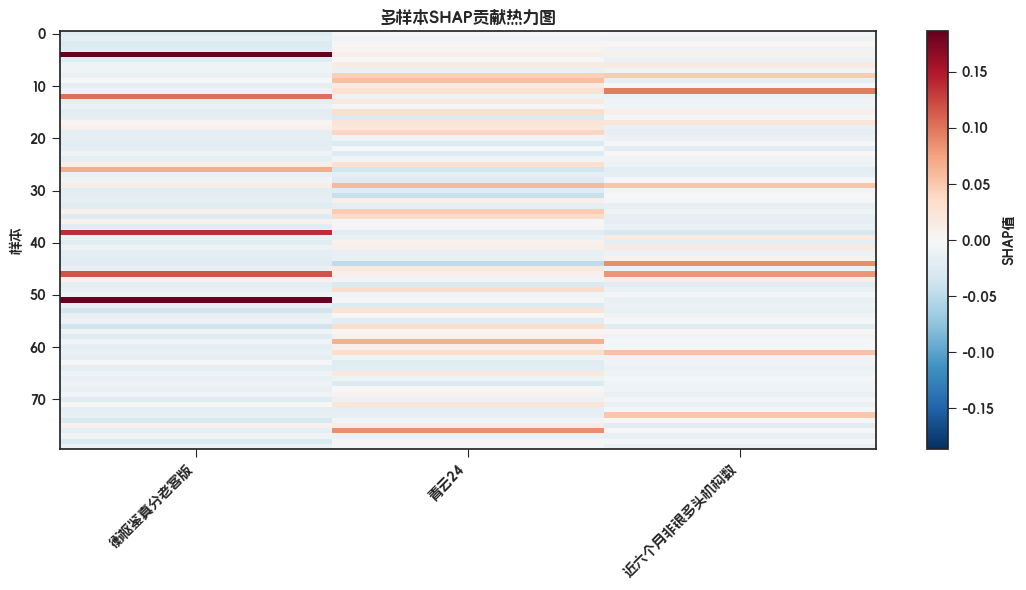

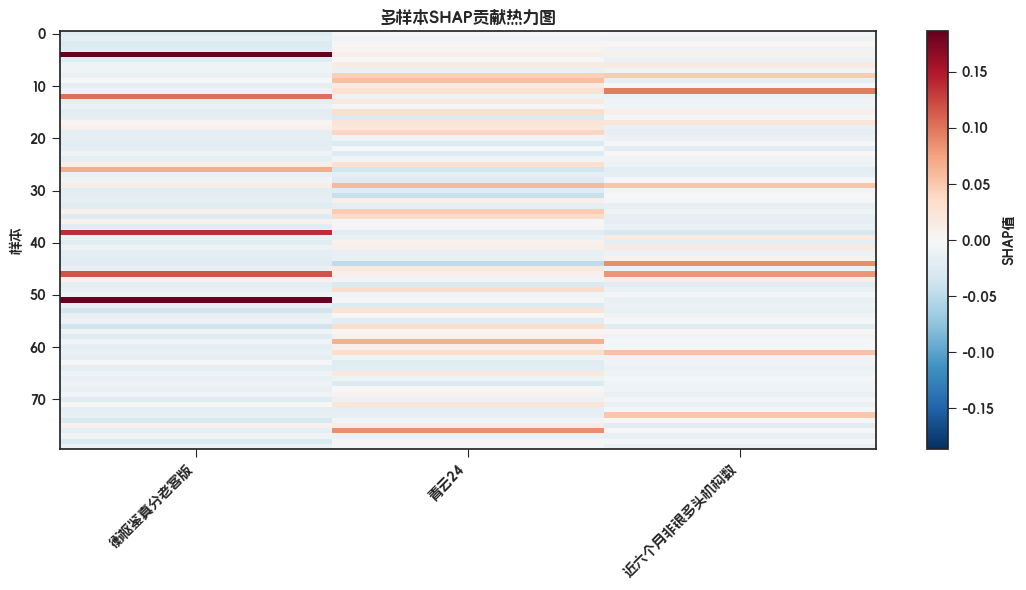

In [11]:
most_important_feature = global_report.iloc[0]["特征"]
print(f"当前最重要特征: {most_important_feature}")
explainer.plot_distribution(explanation, feature=most_important_feature)
explainer.plot_heatmap(explanation, max_display=len(FEATURES))

### 9. 分析相关性、特征聚类和交互效应

In [12]:
feature_shap_correlation = explainer.get_correlation_report(explanation, kind="feature_shap")
shap_correlation_matrix = explainer.get_correlation_report(explanation, kind="shap_shap")
feature_clusters = explainer.get_feature_clusters(explanation, max_clusters=3)
exact_interactions = explainer.get_feature_interactions(result=explanation, top_n=10)
approximate_interactions = explainer.get_approximate_interactions(explanation, top_n=10)

print("特征值与自身 SHAP 贡献的相关性")
display(feature_shap_correlation.round(6))
print("SHAP 贡献之间的相关性")
display(shap_correlation_matrix.round(6))
print("基于 SHAP 贡献相似性的特征聚类")
display(feature_clusters)
print("树模型精确交互")
display(exact_interactions.round(6))
print("模型无关的近似交互")
display(approximate_interactions.round(6))

特征值与自身 SHAP 贡献的相关性


,特征,Pearson相关系数,Spearman相关系数
0,衡枢鉴真分老客版,0.7148,0.3255
1,青云24,-0.5809,-0.6341
2,近六个月非银多头机构数,0.4107,0.1509


SHAP 贡献之间的相关性


,衡枢鉴真分老客版,近六个月非银多头机构数,青云24
衡枢鉴真分老客版,1.0000,-0.0344,0.1221
近六个月非银多头机构数,-0.0344,1.0000,0.0308
青云24,0.1221,0.0308,1.0000


基于 SHAP 贡献相似性的特征聚类


,特征,叶序,聚类编号
0,近六个月非银多头机构数,1,2
1,衡枢鉴真分老客版,2,1
2,青云24,3,3


树模型精确交互


,特征1,特征2,交互强度
0,近六个月非银多头机构数,青云24,0.0065
1,衡枢鉴真分老客版,青云24,0.0059
2,衡枢鉴真分老客版,近六个月非银多头机构数,0.0033


模型无关的近似交互


,特征1,特征2,交互强度,交互类型
0,衡枢鉴真分老客版,青云24,0.1221,近似
1,衡枢鉴真分老客版,近六个月非银多头机构数,0.0344,近似
2,近六个月非银多头机构数,青云24,0.0308,近似


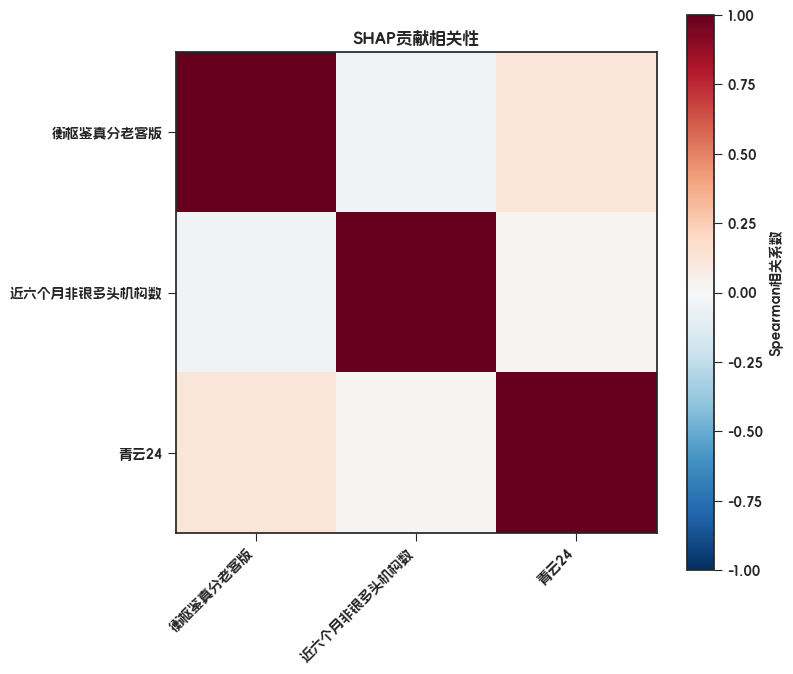

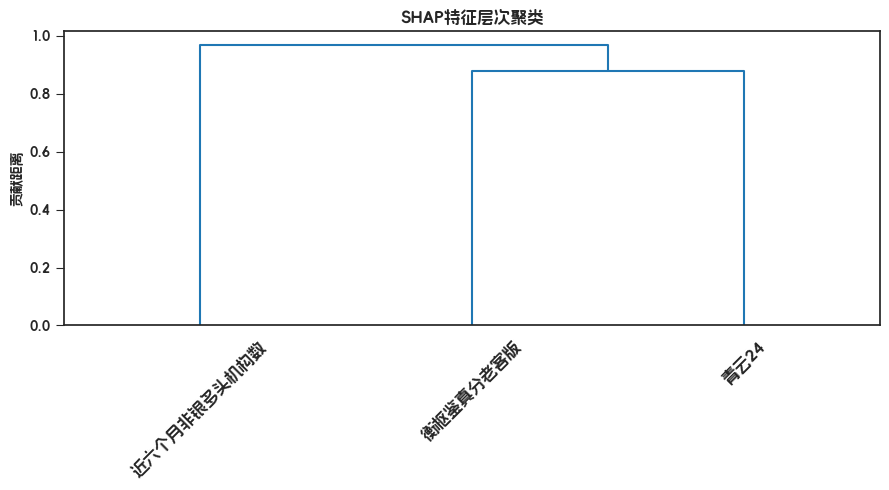

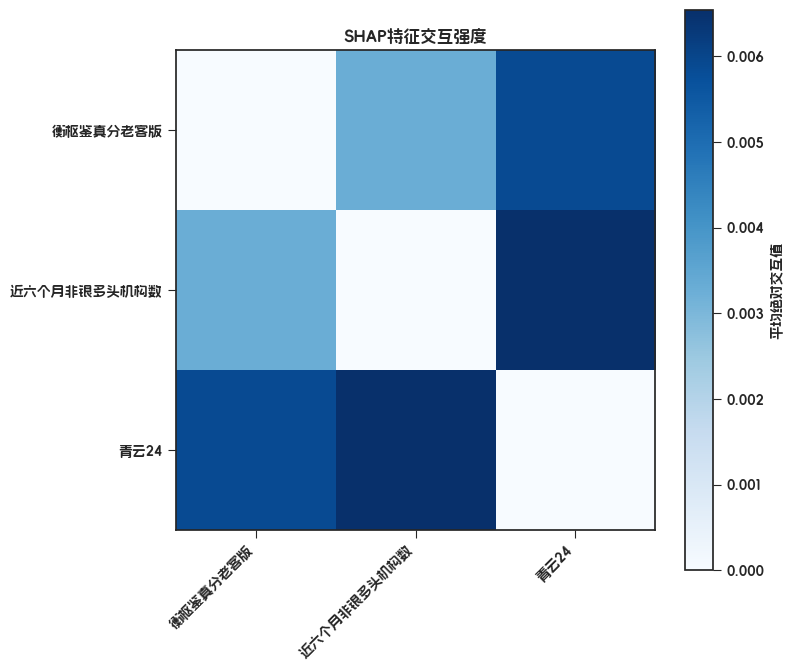

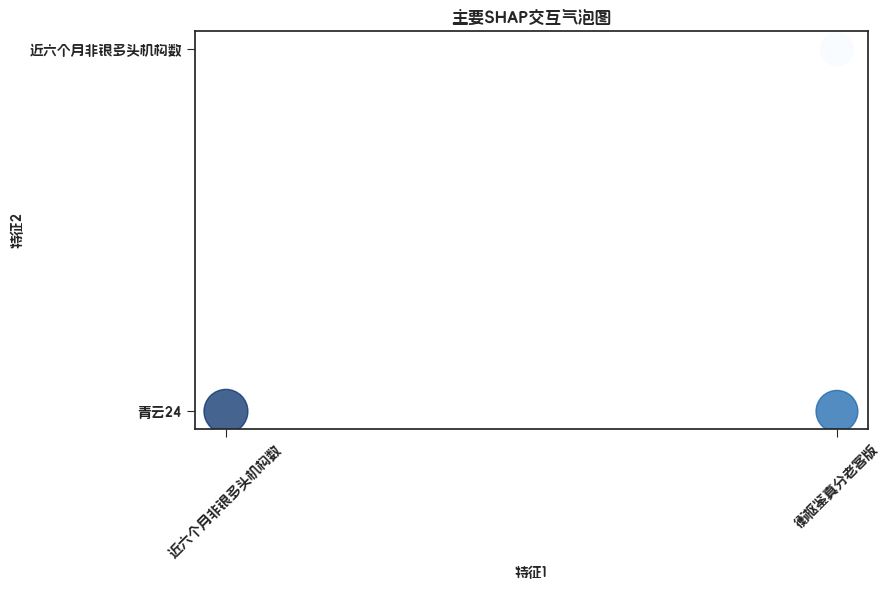

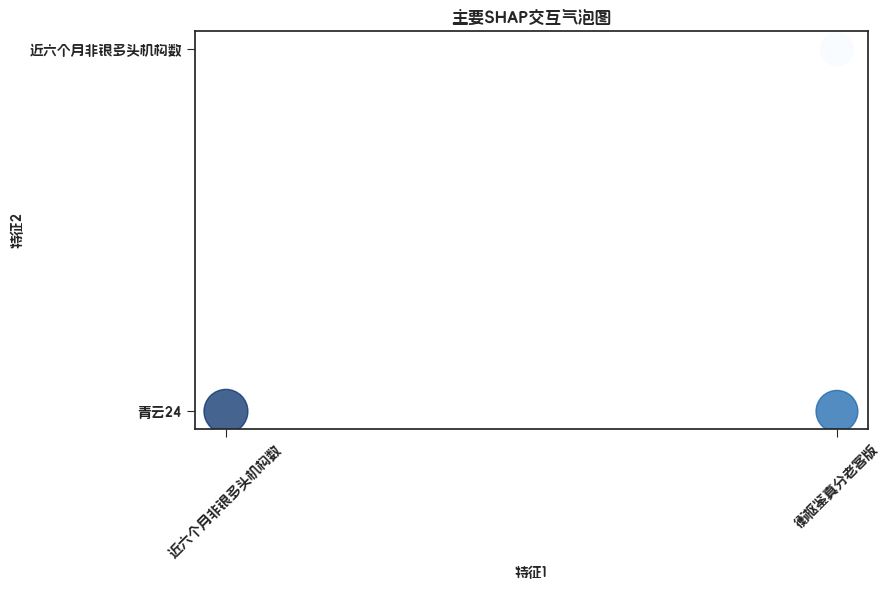

In [13]:
explainer.plot_correlation(explanation)
explainer.plot_feature_clustering(explanation)
explainer.plot_interaction_heatmap(explanation)
explainer.plot_interaction_bubble(explanation, top_n=10)

### 10. 检查解释稳定性

`mode="sample"` 对固定解释结果做样本 Bootstrap，不会重训模型。若要评估重训带来的波动，可改用 `mode="refit"` 并提供训练数据、标签和固定验证集。

In [14]:
sample_stability = explainer.get_stability_report(
    explanation,
    mode="sample",
    n_bootstrap=N_BOOTSTRAP,
    top_k=min(3, len(FEATURES)),
    random_state=RANDOM_STATE,
)
display(sample_stability.round(6))

# 重训稳定性调用示例（运行时间更长，按需取消注释）：
# refit_stability = explainer.get_stability_report(
#     mode="refit",
#     X_train=X_train,
#     y_train=y_train,
#     X_validation=X_test.head(30),
#     n_bootstrap=10,
# )

,特征,稳定性模式,平均绝对SHAP值,置信区间下限,置信区间上限,排名均值,排名标准差,Top-K入选率
0,衡枢鉴真分老客版,样本Bootstrap,0.0224,0.0160,0.0280,1.3000,0.5568,1.0000
1,青云24,样本Bootstrap,0.0197,0.0173,0.0224,1.7500,0.4330,1.0000
2,近六个月非银多头机构数,样本Bootstrap,0.0153,0.0119,0.0188,2.9500,0.2179,1.0000


### 11. 绘制模型解释综合总览

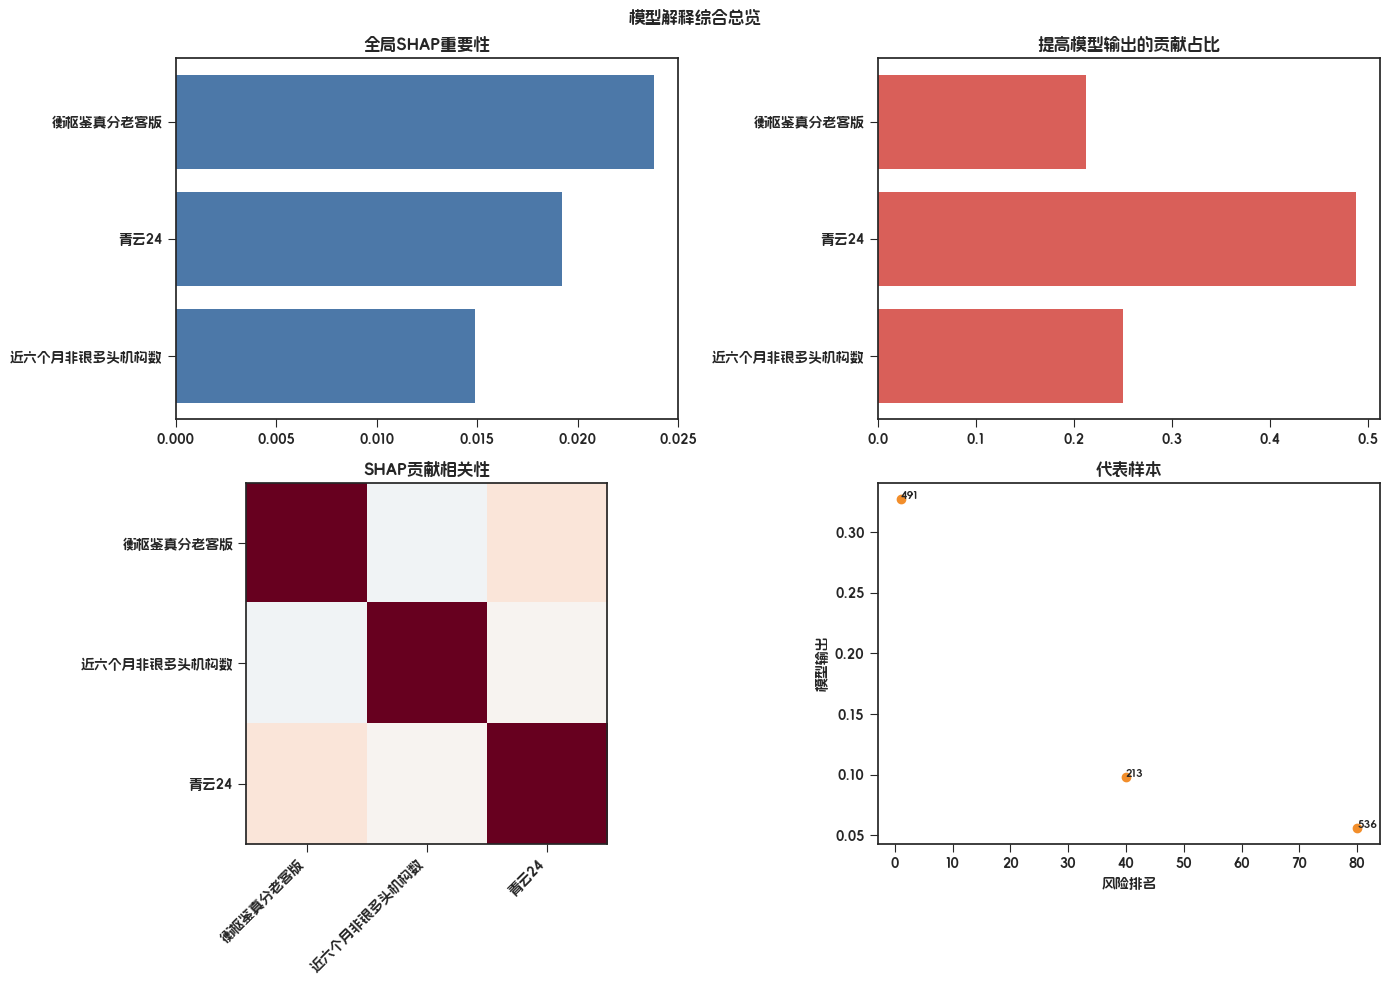

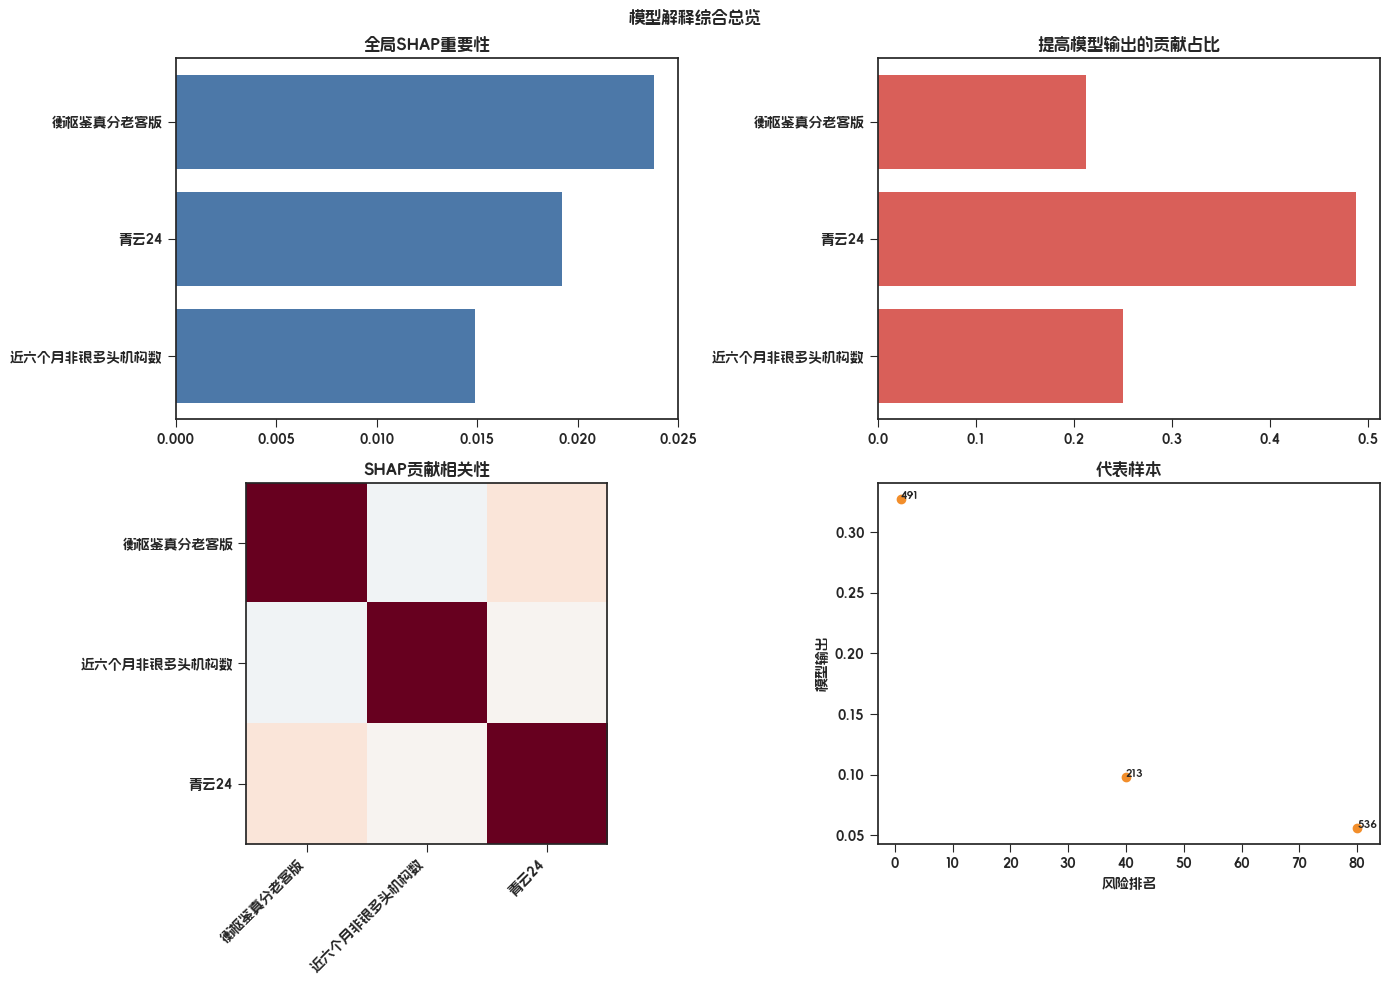

In [15]:
explainer.plot_explanation_overview(explanation, max_display=len(FEATURES))

### 12. 生成带约束的反事实候选方案

以下示例把“衡枢鉴真分老客版”设置为不可变字段，并限制最多变化两个特征。结果只是模型条件下的搜索方案，不能直接视为授信承诺、审批依据或因果干预建议。

In [16]:
highest_risk_position = int(np.argmax(np.asarray(explanation.metadata["模型输出"], dtype=float)))
counterfactual_subject = explanation.data.iloc[[highest_risk_position]]
current_probability = float(model.predict_proba(counterfactual_subject)[0, 1])
target_probability = max(0.0, current_probability - 0.10)

counterfactual_explainer = CounterfactualExplainer(
    model,
    reference_data=X_train,
    constraints={
        "衡枢鉴真分老客版": {"mutable": False},
        "近六个月非银多头机构数": {"min": 0, "direction": "decrease_only", "weight": 1.5},
        "青云24": {"weight": 1.0},
    },
    random_state=RANDOM_STATE,
)
counterfactual_plans = counterfactual_explainer.generate(
    counterfactual_subject,
    target_probability=target_probability,
    max_changes=2,
    top_n=3,
)
display(counterfactual_plans.round(6))

,样本索引,方案编号,是否达标,变更特征数,总成本,预测前值,预测后值,目标值,特征,原值,新值,变化方向,约束检查,失败原因,说明
0,491,1,是,1,0.1600,0.3271,0.2155,0.2271,近六个月非银多头机构数,77.0000,69.0000,减少,通过,None,模型条件下的非因果建议，不代表真实因果效果或授信承诺
1,491,2,是,1,0.3200,0.3271,0.1717,0.2271,近六个月非银多头机构数,77.0000,61.0000,减少,通过,None,模型条件下的非因果建议，不代表真实因果效果或授信承诺
2,491,3,是,1,0.5000,0.3271,0.1564,0.2271,近六个月非银多头机构数,77.0000,52.0000,减少,通过,None,模型条件下的非因果建议，不代表真实因果效果或授信承诺


### 13. 导出包含模型解释页的 Excel 报告

In [17]:
model_report = ModelReport(
    model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_jobs=1,
    explain_config={
        "enabled": True,
        "data": X_test,
        "background_data": X_train,
        "max_samples": 50,
        "n_bootstrap": 10,
        "random_state": RANDOM_STATE,
    },
)
model_report.to_excel(output_path, with_plots=False)
report_sheets = load_workbook(output_path, read_only=True).sheetnames
print(f"报告路径: {output_path}")
print(f"报告工作表: {report_sheets}")

报告路径: E:\workspace\hscredit\examples\model_interpretability_report.xlsx
报告工作表: ['目录', '1-基本信息', '2-模型性能', '3-入模变量分析', '4-稳定性分析', '5-模型参数', '6-模型部署需求', '7-模型解释']


## Checks

### 14. 验证解释结果和报告完整性

In [18]:
reconstructed_output = explanation.base_values + explanation.values.sum(axis=1)
model_output = np.asarray(explanation.metadata["模型输出"], dtype=float)
max_additivity_error = float(np.max(np.abs(reconstructed_output - model_output)))

checks = {
    "ExplanationResult类型正确": isinstance(explanation, ExplanationResult),
    "解释样本数一致": len(explanation.values) == len(explanation.data),
    "解释特征数一致": explanation.values.shape[1] == len(FEATURES),
    "全局报告包含全部特征": set(global_report["特征"]) == set(FEATURES),
    "原因码只使用当前解释样本": set(reason_codes["样本索引"]).issubset(set(explanation.sample_ids)),
    "反事实包含非因果说明": counterfactual_plans["说明"].str.contains("非因果").all(),
    "Excel包含模型解释页": "7-模型解释" in report_sheets,
    "概率尺度加总误差可接受": max_additivity_error < 1e-5,
}
check_table = pd.DataFrame({"检查项": checks.keys(), "是否通过": checks.values()})
display(check_table)
print(f"最大 SHAP 加总误差: {max_additivity_error:.10f}")
assert all(checks.values()), "存在未通过的模型解释检查项"

,检查项,是否通过
0,ExplanationResult类型正确,True
1,解释样本数一致,True
2,解释特征数一致,True
3,全局报告包含全部特征,True
4,原因码只使用当前解释样本,True
5,反事实包含非因果说明,True
6,Excel包含模型解释页,True
7,概率尺度加总误差可接受,True


最大 SHAP 加总误差: 0.0000000102


## Next Steps

- 将 `RandomForestClassifier` 替换为自己的已拟合模型，并保持解释数据的特征名称和顺序一致；
- 二分类默认解释类别 `1`，多分类模型应显式设置 `target_class`；
- 若模型输出越高代表风险越低，请将原因码方向改成 `higher_output_lower_risk`；
- 生产报告可增加样本量、Bootstrap 次数，并结合业务字典完善 `reason_map`；
- 反事实结果上线前应补充合规审查、特征可操作性校验和人工复核。